In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, Birch
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

# Настройка визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## ЗАГРУЗКА И ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ

In [2]:
# Загрузка данных (укажи правильные пути к файлам)
train_df = pd.read_csv('Physical_Activity_Monitoring_unlabeled.csv', index_col=0)

print(f"Размер обучающей выборки: {train_df.shape}")

# Посмотрим на данные
print("\nПервые 5 строк train:")
print(train_df.head())

print("\nТипы данных:")
print(train_df.dtypes.value_counts())

print("\nСтатистика пропусков:")
print(f"Пропуски в train: {train_df.isnull().sum().sum()}")

Размер обучающей выборки: (534601, 52)

Первые 5 строк train:
           handTemperature  handAcc16_1  handAcc16_2  handAcc16_3  handAcc6_1  \
timestamp                                                                       
252.75             34.8750     0.902847      7.45872     6.032490    1.006100   
3652.45            29.7500    -4.069330      3.76168     8.279720   -5.972500   
504.76             34.3750    -2.007540     -9.60180     0.773674   -1.803500   
2801.61            31.9375   -13.262200      5.85443     0.899334  -13.611500   
441.01             33.5000    -0.013940      8.66540     4.398210    0.144153   

           handAcc6_2  handAcc6_3  handGyro1  handGyro2  handGyro3  ...  \
timestamp                                                           ...   
252.75        7.44575    6.303650  -0.021952   0.004114  -0.000752  ...   
3652.45       3.22273    6.908970   0.116054  -0.375968  -0.012890  ...   
504.76       -9.58937    1.073680   0.020131   0.042189  -0.011507  ..

## ИССЛЕДОВАТЕЛЬСКИЙ АНАЛИЗ ДАННЫХ (EDA)


Статистика признаков:
       handTemperature    handAcc16_1    handAcc16_2    handAcc16_3  \
count    530560.000000  530560.000000  530560.000000  530560.000000   
mean         32.451221      -4.435286       3.241949       4.079375   
std           1.754847       7.062004       7.224031       3.831257   
min          27.500000    -114.755000     -82.550900     -73.949700   
25%          31.312500      -9.076360       0.682775       1.588777   
50%          32.875000      -5.465610       3.089205       4.157125   
75%          33.812500       0.383679       5.559742       6.864212   
max          35.250000      60.912600     155.532000      78.480100   

          handAcc6_1     handAcc6_2     handAcc6_3      handGyro1  \
count  530560.000000  530560.000000  530560.000000  530560.000000   
mean       -4.375896       3.218250       4.262513      -0.008852   
std         7.068961       6.864782       3.822053       1.160112   
min       -61.214700     -61.824200     -61.577100     -19.69

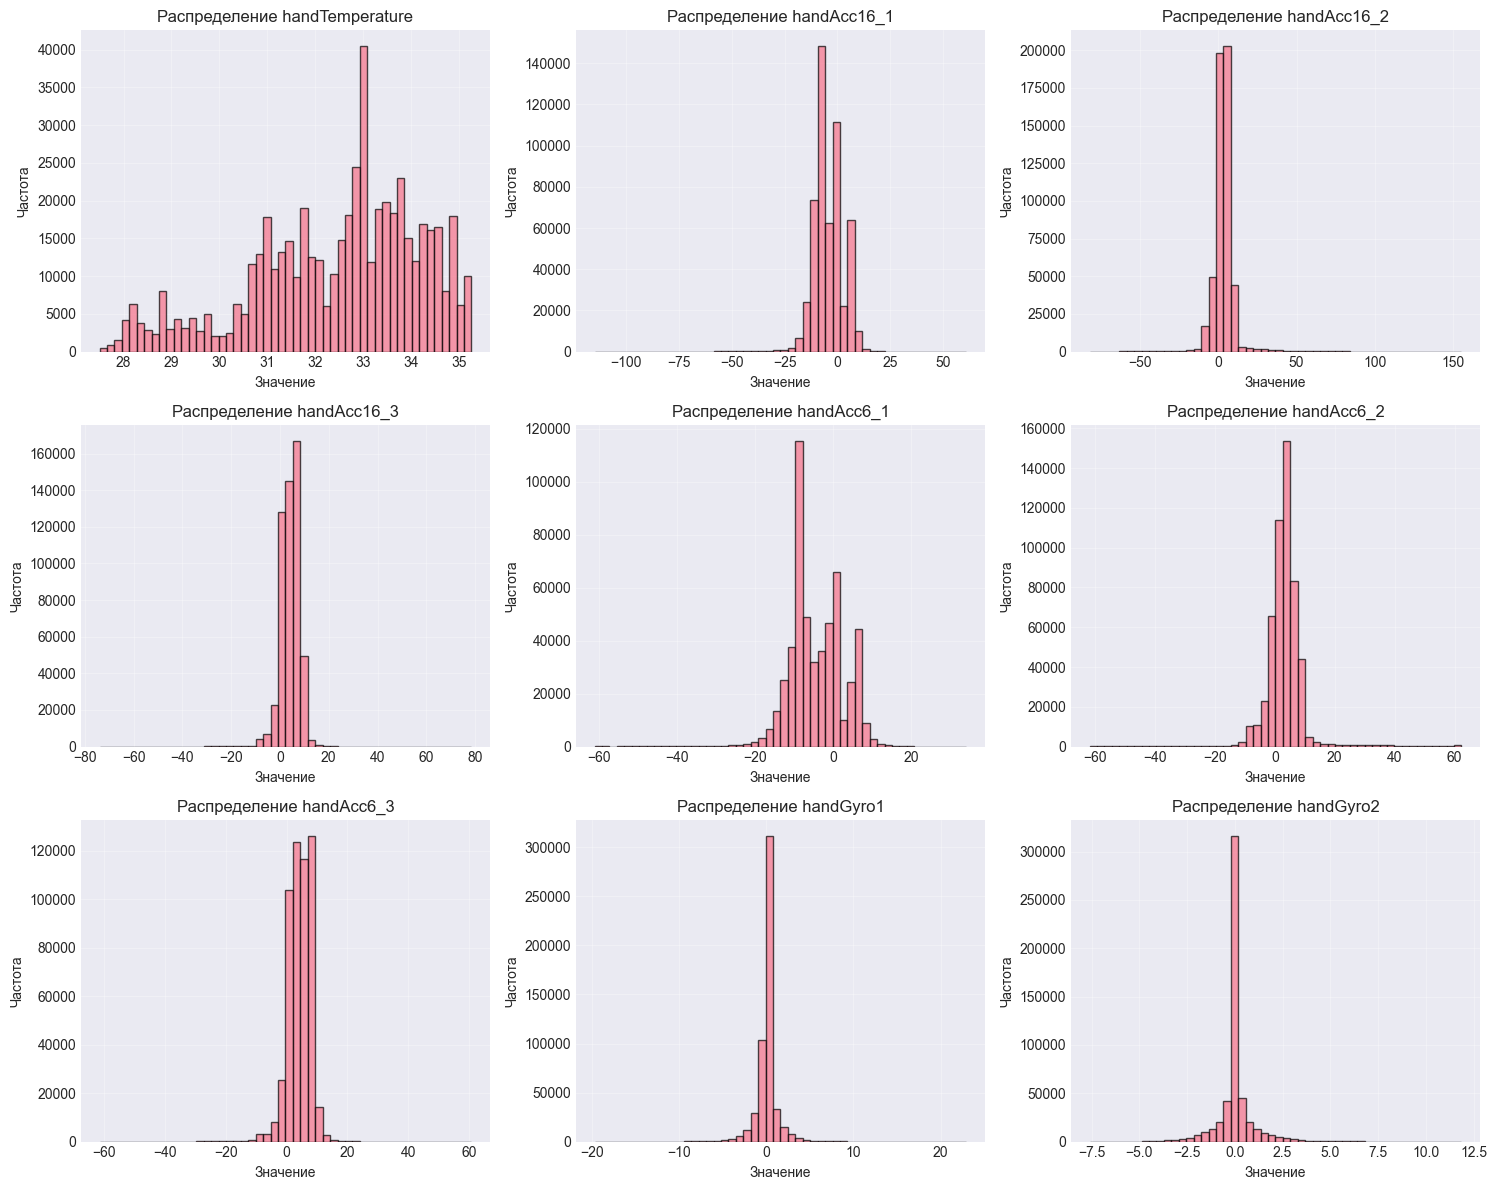

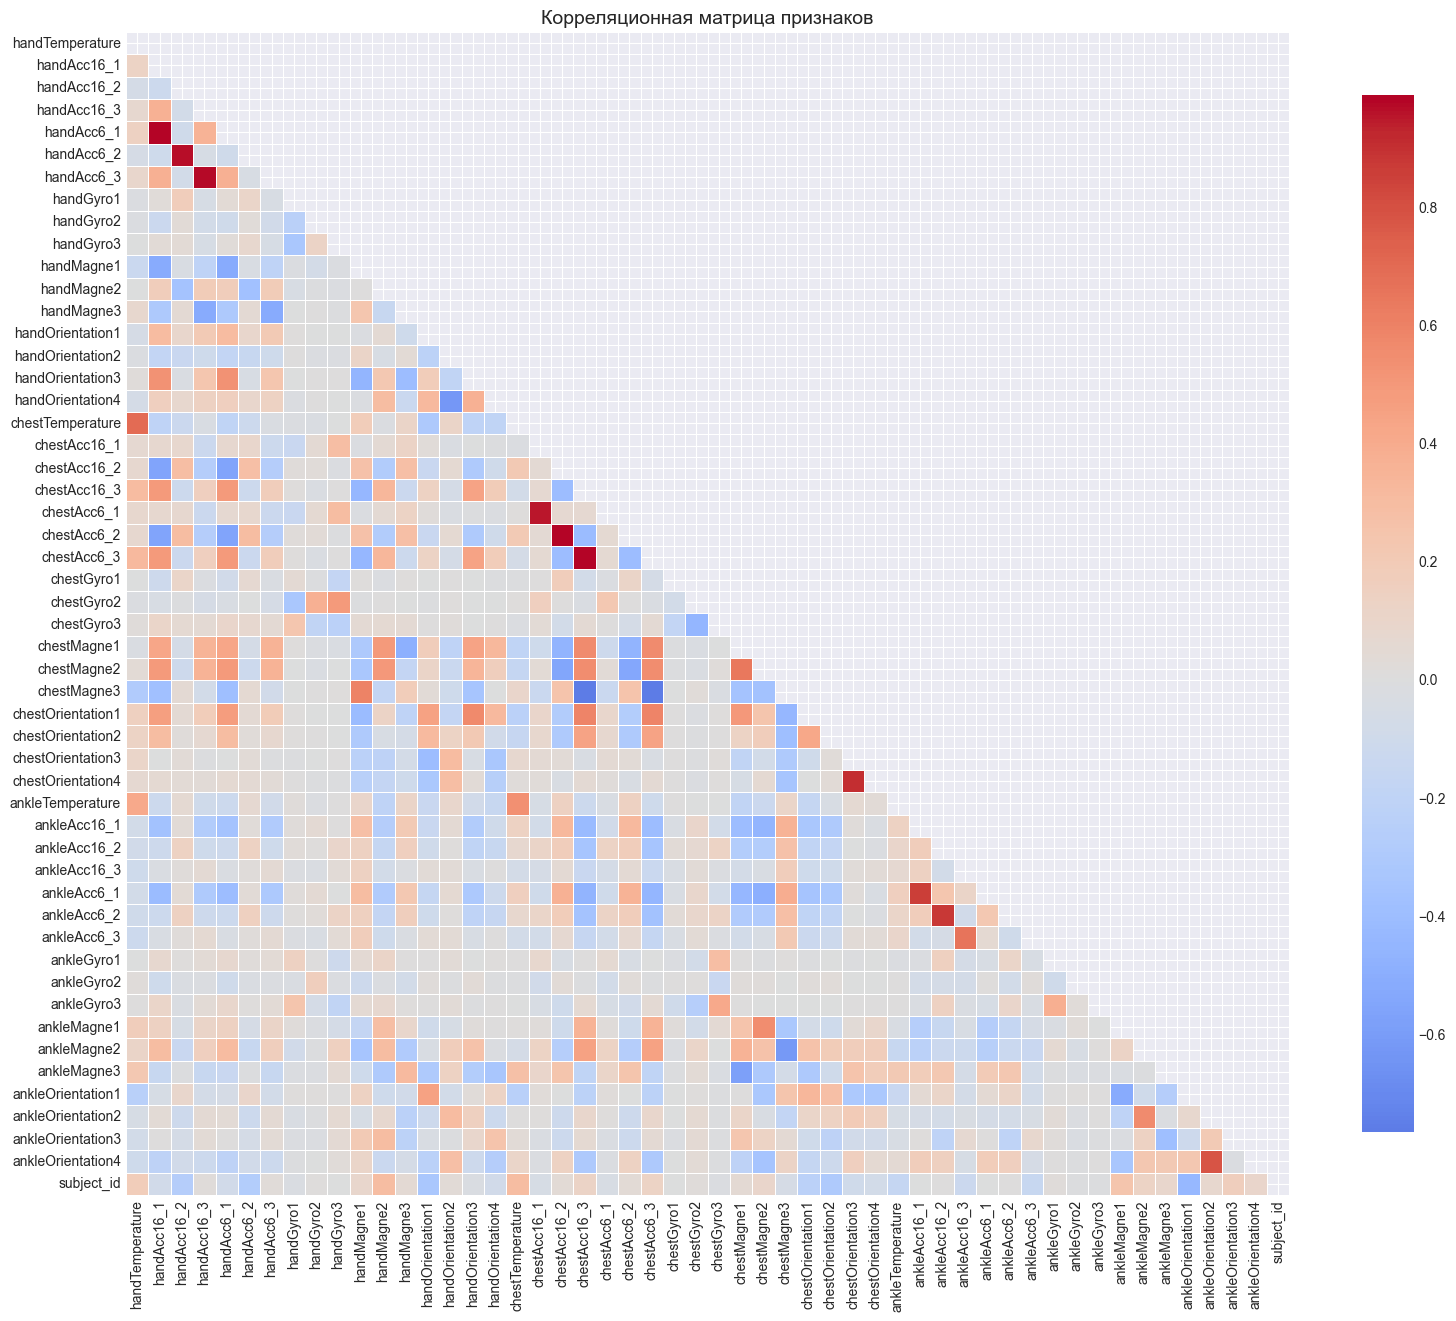


Сильные корреляции (|r| > 0.8):
  handAcc16_1 — handAcc6_1: 0.981
  handAcc16_2 — handAcc6_2: 0.964
  handAcc16_3 — handAcc6_3: 0.972
  chestAcc16_1 — chestAcc6_1: 0.956
  chestAcc16_2 — chestAcc6_2: 0.985
  chestAcc16_3 — chestAcc6_3: 0.991
  chestOrientation3 — chestOrientation4: 0.906
  ankleAcc16_1 — ankleAcc6_1: 0.859
  ankleAcc16_2 — ankleAcc6_2: 0.876

3. ПРЕДОБРАБОТКА ДАННЫХ
Размер данных после предобработки: (534601, 52)
Размер данных до импутации: (534601, 52)
Количество NaN до импутации: 125732
Количество NaN после импутации: 0

Анализ PCA...


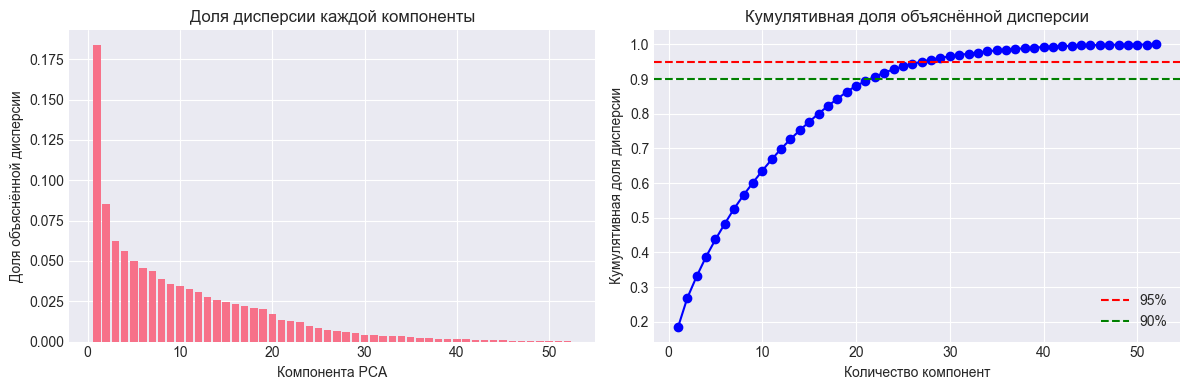


Оптимальное количество компонент (95% дисперсии): 27
Размерность после PCA: (534601, 27)


In [3]:
# Базовые статистики
print("\nСтатистика признаков:")
print(train_df.describe())

# Визуализация распределений
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

# Выбираем несколько случайных признаков для визуализации
sample_cols = train_df.columns[:9]

for i, col in enumerate(sample_cols):
    axes[i].hist(train_df[col], bins=50, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Распределение {col}')
    axes[i].set_xlabel('Значение')
    axes[i].set_ylabel('Частота')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Корреляционная матрица
plt.figure(figsize=(16, 14))
corr_matrix = train_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Корреляционная матрица признаков', fontsize=14)
plt.tight_layout()
plt.show()

# Вывод сильных корреляций
print("\nСильные корреляции (|r| > 0.8):")
strong_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            strong_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], 
                               corr_matrix.iloc[i, j]))

for col1, col2, corr in strong_corr[:10]:
    print(f"  {col1} — {col2}: {corr:.3f}")

# ==================== 3. ПРЕДОБРАБОТКА ДАННЫХ ====================
print("\n" + "=" * 60)
print("3. ПРЕДОБРАБОТКА ДАННЫХ")
print("=" * 60)

# 3.1 Обработка выбросов (метод IQR)
def remove_outliers_iqr(df, factor=1.5):
    """Удаление выбросов методом IQR"""
    df_clean = df.copy()
    q1 = df_clean.quantile(0.25)
    q3 = df_clean.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - factor * iqr
    upper_bound = q3 + factor * iqr
    
    # Заменяем выбросы на границы
    for col in df_clean.columns:
        df_clean[col] = df_clean[col].clip(lower_bound[col], upper_bound[col])
    
    return df_clean

# 3.2 Нормализация данных
def preprocess_data(df, scaler_type='standard'):
    """Предобработка данных: очистка и нормализация"""
    # Очистка от выбросов
    df_clean = remove_outliers_iqr(df)
    
    # Выбор скейлера
    if scaler_type == 'standard':
        scaler = StandardScaler()
    elif scaler_type == 'minmax':
        scaler = MinMaxScaler()
    else:
        scaler = RobustScaler()
    
    # Нормализация
    scaled_data = scaler.fit_transform(df_clean)
    df_scaled = pd.DataFrame(scaled_data, columns=df.columns, index=df.index)
    
    return df_scaled, scaler

# Применяем предобработку
train_processed, scaler = preprocess_data(train_df, scaler_type='robust')
print(f"Размер данных после предобработки: {train_processed.shape}")


from sklearn.impute import SimpleImputer

# ... (предыдущий код, где создаётся train_processed, например, после скейлера) ...

print(f"Размер данных до импутации: {train_processed.shape}")
print(f"Количество NaN до импутации: {train_processed.isnull().sum().sum()}")

# 3.2.1. Импутация пропусков (ДОБАВИТЬ ЭТУ ЧАСТЬ)
# Создаём импутер, который будет заполнять пропуски средним значением по столбцу
# strategy может быть 'mean', 'median', 'most_frequent' или 'constant'
imputer = SimpleImputer(strategy='median') # или 'mean'
train_processed_imputed = imputer.fit_transform(train_processed)

# Преобразуем обратно в DataFrame, чтобы сохранить имена колонок
train_processed = pd.DataFrame(train_processed_imputed, 
                               columns=train_processed.columns, 
                               index=train_processed.index)

print(f"Количество NaN после импутации: {train_processed.isnull().sum().sum()}")


# 3.3 PCA для снижения размерности
print("\nАнализ PCA...")
pca = PCA()
pca_result = pca.fit_transform(train_processed)

# Определяем оптимальное количество компонент
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio)
plt.xlabel('Компонента PCA')
plt.ylabel('Доля объяснённой дисперсии')
plt.title('Доля дисперсии каждой компоненты')

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'bo-')
plt.xlabel('Количество компонент')
plt.ylabel('Кумулятивная доля дисперсии')
plt.axhline(y=0.95, color='r', linestyle='--', label='95%')
plt.axhline(y=0.90, color='g', linestyle='--', label='90%')
plt.legend()
plt.title('Кумулятивная доля объяснённой дисперсии')

plt.tight_layout()
plt.show()

# Выбираем количество компонент для 95% дисперсии
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"\nОптимальное количество компонент (95% дисперсии): {n_components_95}")

# Применяем PCA для уменьшения размерности
pca_reduced = PCA(n_components=n_components_95)
data_pca = pca_reduced.fit_transform(train_processed)
print(f"Размерность после PCA: {data_pca.shape}")

## ОБУЧЕНИЕ МОДЕЛЕЙ И ПОДБОР ГИПЕРПАРАМЕТРОВ

Используем подвыборку из 5000 объектов для подбора параметров
Выполняется поиск оптимального k...
  k=2: silhouette=0.0506, inertia=182084
  k=3: silhouette=0.1683, inertia=149090
  k=4: silhouette=0.1239, inertia=142004
  k=5: silhouette=0.1141, inertia=138004
  k=6: silhouette=0.0834, inertia=133145
  k=7: silhouette=0.1419, inertia=130498
  k=8: silhouette=0.1064, inertia=125697
  k=9: silhouette=0.0739, inertia=124820
  k=10: silhouette=0.1082, inertia=120053
  k=11: silhouette=0.1161, inertia=119691
  k=12: silhouette=0.1637, inertia=114555
  k=13: silhouette=0.1352, inertia=113256
  k=14: silhouette=0.1043, inertia=109997

Оптимальное k = 3 (silhouette = 0.1683)
Время поиска: 1.5 сек


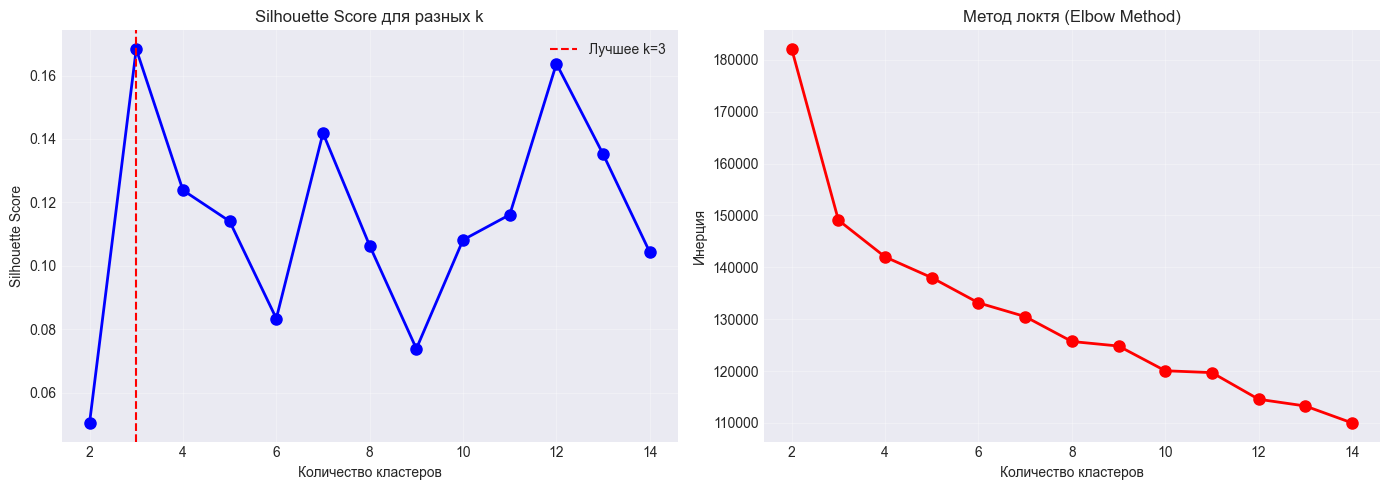

In [7]:
from sklearn.cluster import KMeans, MiniBatchKMeans, AgglomerativeClustering, DBSCAN, Birch
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
import time

# Определяем размер подвыборки для ускорения (если данных много)
USE_SUBSAMPLE = len(data_pca) > 10000
SUBSAMPLE_SIZE = min(5000, len(data_pca))

if USE_SUBSAMPLE:
    np.random.seed(42)
    subsample_idx = np.random.choice(len(data_pca), SUBSAMPLE_SIZE, replace=False)
    data_subsample = data_pca[subsample_idx]
    print(f"Используем подвыборку из {SUBSAMPLE_SIZE} объектов для подбора параметров")
else:
    data_subsample = data_pca
    print(f"Используем все {len(data_pca)} объектов")

# ==================== 1. ОПРЕДЕЛЕНИЕ ОПТИМАЛЬНОГО K ====================

k_range = range(2, min(15, data_subsample.shape[0] // 50 + 2))
silhouette_scores = []
inertias = []
best_k = 2
best_sil = -1

print("Выполняется поиск оптимального k...")
start_time = time.time()

for k in k_range:
    # Используем MiniBatchKMeans для ускорения
    km = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=256, n_init=3, max_iter=100)
    labels = km.fit_predict(data_subsample)
    
    inertias.append(km.inertia_)
    
    # Считаем silhouette только если больше 1 кластера
    if len(set(labels)) > 1:
        sil = silhouette_score(data_subsample, labels)
        silhouette_scores.append(sil)
        print(f"  k={k}: silhouette={sil:.4f}, inertia={km.inertia_:.0f}")
        if sil > best_sil:
            best_sil = sil
            best_k = k
    else:
        silhouette_scores.append(-1)
        print(f"  k={k}: только один кластер")

elapsed = time.time() - start_time
print(f"\nОптимальное k = {best_k} (silhouette = {best_sil:.4f})")
print(f"Время поиска: {elapsed:.1f} сек")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, silhouette_scores, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Количество кластеров')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Score для разных k')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=best_k, color='red', linestyle='--', label=f'Лучшее k={best_k}')
axes[0].legend()

axes[1].plot(k_range, inertias, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Количество кластеров')
axes[1].set_ylabel('Инерция')
axes[1].set_title('Метод локтя (Elbow Method)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Дальше не могу выполнить задание так как не понимаю как убрать большие данные (модели очень долго работают)